|<img style="float:left;" src="../images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|


### Exercice 8B1, écoulement d'un fluide de type Power-Law sur un film. L'exercice est une reprise de la section 2.2 (BSL Transport Phenomena) pour l'écoulement d'un fluide sur un plan incliné.

Le développement fait dans Transport Phenomena sera répété ici en développant les solutions avec le calculateur formel sympy et en traçant la solution avec sympy.plot.

La difficulté rencontrée dans cet exemple par rapport à la section 2.2 de Transport Phenomena est dans le type de solution qui est rencontrée. La valeur de n, le coefficient de consistance de la Power-Law, donne lieu à des solutions multiples. On verra comment traiter celles-ci.
<img src='http:\\pierreproulx.pheno.ca\Chap-2-Section-2-2.png'>


In [1]:
#
# Initialiser sympy et l'affichage des équation
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline
#
# pose des variables, paramètres et fonctions
#
x,rho,g,m,delta,beta,W=sp.symbols('x,rho,g,m,delta,beta,W')
n=sp.symbols('n',positive=True)
tau=sp.Function('tau_xz')(x)
v_z=sp.Function('v_z')(x)
#
# Loi de comportement de type Power-Law et bilan de forces
#
tau_xz=m*(-sp.Derivative(v_z,x))**n
#
# Le bilan de forces est identique à celui de la section 2.2 , mais le
# fluide est Power-Law alors l'équation après substitution est différente
#
eq1=sp.Eq(tau_xz-rho*g*sp.cos(beta)*x,0)
display(eq1)

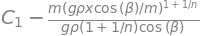

In [2]:
#
# Solution
#
v_z=sp.dsolve(eq1,v_z).rhs
display(v_z)

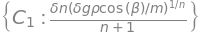

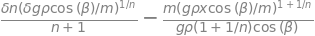

In [3]:
# La constante inconnue est obtenue avec la condition vz(r)=0 en r=R
#
constante=sp.solve((v_z.subs(x,delta),0),sp.symbols('C1'))
display(constante)
v_z=v_z.subs(constante)
display(v_z)

'Débit Power-Law'

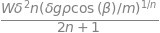

'Débit Newtonien'

In [4]:
# Calculons le débit Power-law: 
#
#
debit=W*sp.integrate(v_z,(x,0,delta))
display('Débit Power-Law')
display(debit.simplify())
#
# Quel serait le débit si le fluide était Newtonien?
#
debit_Newtonien=debit.subs(n,1)
debit_Newtonien=debit_Newtonien.subs(m,sp.symbols('mu'))
display('Débit Newtonien')
display(debit_Newtonien.simplify())

On voit bien que les résultats Newtoniens concordent avec les résultats obtenus au chapitre 2.

In [5]:
# Maintenant traçons le profil en donnant des valeurs de paramètres réalistes
#
from ipywidgets import *
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=5,4
def f(N):
    dico={'rho':800, 'm':1, 'delta':0.003,'g':9.81,'beta':sp.pi/4}
    v_z1=v_z.subs(dico).subs(n,N)
    vmax=v_z1.subs(x,0)
    p=sp.plot(v_z1/vmax,(x,0,delta.subs(dico)),legend=True,show=False)
    p[0].label='Vmax='+str(vmax)[0:6]+' m/sec'
    p.show()
    return
graphe=interactive(f,N=(0.3,1.8,0.1))

In [6]:
display(graphe)  # le coefficient m est maintenu constant, donc vmax change beaucoup.

interactive(children=(FloatSlider(value=1.0, description='N', max=1.8, min=0.3), Output()), _dom_classes=('wid…